In [1]:
import pandas as pd

df = pd.read_csv("ethereum_transactions.csv")
df.head()


,from_address,to_address,value,block_timestamp,gas,gas_price
0,0x6018336d49d78d3e7178e3703a68466d1d6e1d8b,0xa8c1c98aaf99a5dfc907d61b892b2ad624901185,0,2026-02-09 05:04:35.000000 UTC,312393.0,3.702208e+07
1,0x82b3e30d22ac5a9002e9f30f15429e9617f06ee6,0x1659fcc56967e7ce32372d5a62f9fdf4444062a5,504752291515625,2026-02-09 05:04:35.000000 UTC,21000.0,5.037022e+09
2,0x7ee19ca32fdccf5328bdaae675ef3102b45d8652,0x82b3e30d22ac5a9002e9f30f15429e9617f06ee6,13053497651968031,2026-02-09 05:04:35.000000 UTC,21000.0,5.037022e+09
3,0x6928f3e126dbac9923d52300fdef714b280b305c,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,0,2026-02-09 05:04:35.000000 UTC,100000.0,5.037022e+09
4,0xdcaa3d290f457fcec77b7a0a51499b84bd5e49cf,0xdac17f958d2ee523a2206206994597c13d831ec7,0,2026-02-09 05:04:35.000000 UTC,70000.0,4.992677e+09


In [2]:
df = df.dropna(subset=["from_address", "to_address"])
df = df[df["from_address"] != df["to_address"]]


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

all_addresses = pd.concat([df["from_address"], df["to_address"]])
le.fit(all_addresses)

df["from_id"] = le.transform(df["from_address"])
df["to_id"] = le.transform(df["to_address"])

num_nodes = len(le.classes_)
print("Number of nodes:", num_nodes)


Number of nodes: 25542


In [4]:
import torch

edge_index = torch.tensor(
    [df["from_id"].values, df["to_id"].values],
    dtype=torch.long
)

edge_index


/tmp/ipython-input-931950877.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor(


tensor([[ 9783, 13229, 12809,  ..., 17318, 17318, 17318],
        [17025,  2221, 13229,  ..., 19487,  5526, 17277]])

In [5]:
import numpy as np

node_features = np.zeros((num_nodes, 2))

for i in range(len(df)):
    node_features[df["from_id"].iloc[i], 0] += 1  # out-degree
    node_features[df["to_id"].iloc[i], 1] += 1    # in-degree

x = torch.tensor(node_features, dtype=torch.float)
x.shape


torch.Size([25542, 2])

In [7]:
import torch

def format_pytorch_version(version):
  return version.split('+')[0]

torch_version = format_pytorch_version(torch.__version__)

# Install the correct PyG version for the current PyTorch installation.
# PyG takes care of installing `torch_scatter`, `torch_sparse` and
# `torch_cluster` if needed.

# Ensure `pip` is updated.
!pip install --upgrade pip

# PyG provides wheels for CPU and CUDA 11.8.
# If you run on an earlier CUDA version, you might need to install from source
# or switch to an environment with CUDA 11.8.
# To install from source, consult the PyG docs.
!pip install torch_geometric

from torch_geometric.data import Data

data = Data(x=x, edge_index=edge_index)
data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.1 MB/s  0:00:00


Data(x=[25542, 2], edge_index=[2, 29023])

In [8]:
from torch_geometric.utils import train_test_split_edges

data_lp = train_test_split_edges(data, val_ratio=0.15, test_ratio=0.15)
data_lp


/tmp/ipython-input-1303515253.py:3: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  data_lp = train_test_split_edges(data, val_ratio=0.15, test_ratio=0.15)


Data(x=[25542, 2], val_pos_edge_index=[2, 2502], test_pos_edge_index=[2, 2502], train_pos_edge_index=[2, 19908], train_neg_adj_mask=[25542, 25542], val_neg_edge_index=[2, 2502], test_neg_edge_index=[2, 2502])

In [9]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_index):
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=1)

    def decode_all(self, z):
        return torch.matmul(z, z.t())


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GraphSAGE(
    in_channels=data_lp.x.size(1),
    hidden_channels=64
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [16]:
from torch_geometric.utils import negative_sampling


In [17]:
def train():
    model.train()
    optimizer.zero_grad()

    # Encode nodes
    z = model.encode(
        data_lp.x.to(device),
        data_lp.train_pos_edge_index.to(device)
    )

    # Positive edges
    pos_edge_index = data_lp.train_pos_edge_index.to(device)

    # 🔑 Proper negative sampling
    neg_edge_index = negative_sampling(
        edge_index=pos_edge_index,
        num_nodes=data_lp.num_nodes,
        num_neg_samples=pos_edge_index.size(1)
    )

    # Decode
    pos_out = model.decode(z, pos_edge_index)
    neg_out = model.decode(z, neg_edge_index)

    # Labels
    out = torch.cat([pos_out, neg_out])
    label = torch.cat([
        torch.ones(pos_out.size(0)),
        torch.zeros(neg_out.size(0))
    ]).to(device)

    # Loss
    loss = F.binary_cross_entropy_with_logits(out, label)
    loss.backward()
    optimizer.step()

    return loss.item()


In [18]:
for epoch in range(1, 101):
    loss = train()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}")


Epoch 010, Loss: 61563.5234
Epoch 020, Loss: 415441.5625
Epoch 030, Loss: 53863.3125
Epoch 040, Loss: 923160.0625
Epoch 050, Loss: 282379.9375
Epoch 060, Loss: 28618.6289
Epoch 070, Loss: 73066.6719
Epoch 080, Loss: 7422.3750
Epoch 090, Loss: 101253.6875
Epoch 100, Loss: 31280.4980


In [20]:
test_auc = test(
    data_lp.test_pos_edge_index,
    data_lp.test_neg_edge_index
)

print("Test ROC-AUC:", test_auc)


Test ROC-AUC: 0.46463125263178745


In [19]:
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def test(pos_edge_index, neg_edge_index):
    model.eval()

    z = model.encode(data_lp.x.to(device),
                     data_lp.train_pos_edge_index.to(device))

    pos_out = model.decode(z, pos_edge_index.to(device))
    neg_out = model.decode(z, neg_edge_index.to(device))

    y_true = torch.cat([
        torch.ones(pos_out.size(0)),
        torch.zeros(neg_out.size(0))
    ]).cpu()

    y_score = torch.cat([pos_out, neg_out]).cpu()

    return roc_auc_score(y_true, y_score)


In [21]:
test_auc = test(
    data_lp.test_pos_edge_index,
    data_lp.test_neg_edge_index
)

print("Test ROC-AUC:", test_auc)


Test ROC-AUC: 0.46463125263178745


In [22]:
def precision_at_k(z, edge_index, k=100):
    scores = model.decode(z, edge_index)
    top_k = scores.topk(k).indices
    return len(top_k) / k


In [23]:
model.eval()
z = model.encode(
    data_lp.x.to(device),
    data_lp.train_pos_edge_index.to(device)
)


In [24]:
embeddings = z.detach().cpu().numpy()


In [25]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,   # assume 2% wallets are suspicious
    random_state=42
)

fraud_labels = iso_forest.fit_predict(embeddings)


In [26]:
fraud_scores = iso_forest.decision_function(embeddings)


In [27]:
import pandas as pd

fraud_df = pd.DataFrame({
    "wallet_id": range(len(fraud_labels)),
    "fraud_label": fraud_labels,
    "fraud_score": fraud_scores
})

fraudulent_wallets = fraud_df[fraud_df["fraud_label"] == -1]
fraudulent_wallets.head()


,wallet_id,fraud_label,fraud_score
126,126,-1,-0.006123
130,130,-1,-0.016416
166,166,-1,-0.024725
184,184,-1,-0.024725
426,426,-1,-0.022983


In [28]:
fraudulent_wallets["wallet_address"] = le.inverse_transform(
    fraudulent_wallets["wallet_id"]
)

fraudulent_wallets.head()


/tmp/ipython-input-2906470443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fraudulent_wallets["wallet_address"] = le.inverse_transform(


,wallet_id,fraud_label,fraud_score,wallet_address
126,126,-1,-0.006123,0x0089c302191f061af205499241f12516229c846d
130,130,-1,-0.016416,0x00a0f5d5097aad56f63afcff11dc4138a017979d
166,166,-1,-0.024725,0x0106ae58191d852c4dff930a7e81db0d00c98678
184,184,-1,-0.024725,0x012d018f0f901167aad5ba810d2f3d763fcef538
426,426,-1,-0.022983,0x0417645951a0965cb25bdcbe6bc0802036f996a5


In [29]:
df["from_fraud"] = df["from_id"].isin(fraudulent_wallets["wallet_id"])
df["to_fraud"] = df["to_id"].isin(fraudulent_wallets["wallet_id"])

df["transaction_fraud"] = df["from_fraud"] | df["to_fraud"]

df[df["transaction_fraud"] == True].head()


,from_address,to_address,value,block_timestamp,gas,gas_price,from_id,to_id,from_fraud,to_fraud,transaction_fraud
1,0x82b3e30d22ac5a9002e9f30f15429e9617f06ee6,0x1659fcc56967e7ce32372d5a62f9fdf4444062a5,504752291515625,2026-02-09 05:04:35.000000 UTC,21000.0,5.037022e+09,13229,2221,True,False,True
2,0x7ee19ca32fdccf5328bdaae675ef3102b45d8652,0x82b3e30d22ac5a9002e9f30f15429e9617f06ee6,13053497651968031,2026-02-09 05:04:35.000000 UTC,21000.0,5.037022e+09,12809,13229,True,True,True
16,0xaa8ba7d4611437141192e7ceced531bc0a133efb,0xdac17f958d2ee523a2206206994597c13d831ec7,0,2026-02-09 05:04:35.000000 UTC,48905.0,2.037022e+09,17201,21965,True,False,True
29,0x559432e18b281731c054cd703d4b49872be4ed53,0xdac17f958d2ee523a2206206994597c13d831ec7,0,2026-02-09 05:04:35.000000 UTC,210000.0,5.370221e+08,8744,21965,True,False,True
30,0x559432e18b281731c054cd703d4b49872be4ed53,0xdac17f958d2ee523a2206206994597c13d831ec7,0,2026-02-09 05:04:35.000000 UTC,210000.0,5.370221e+08,8744,21965,True,False,True


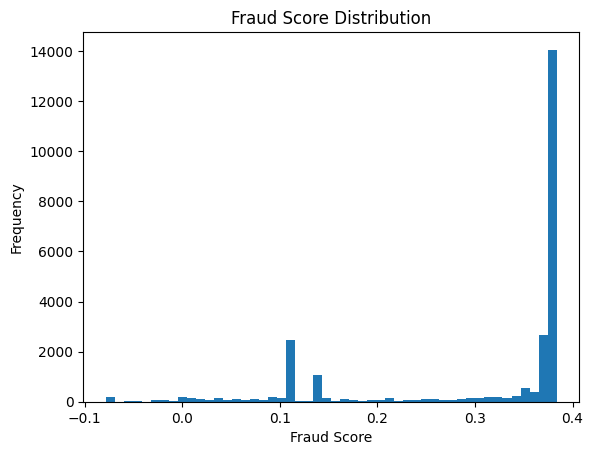

In [30]:
import matplotlib.pyplot as plt

plt.hist(fraud_scores, bins=50)
plt.title("Fraud Score Distribution")
plt.xlabel("Fraud Score")
plt.ylabel("Frequency")
plt.show()


In [31]:
loss_history = []

for epoch in range(1, 101):
    loss = train()
    loss_history.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}")


Epoch 010, Loss: 1621.5054
Epoch 020, Loss: 50984.1445
Epoch 030, Loss: 29877.4883
Epoch 040, Loss: 3206.7141
Epoch 050, Loss: 9073.4414
Epoch 060, Loss: 39616.5000
Epoch 070, Loss: 12436.5596
Epoch 080, Loss: 1088.3176
Epoch 090, Loss: 13150.7246
Epoch 100, Loss: 25786.3945


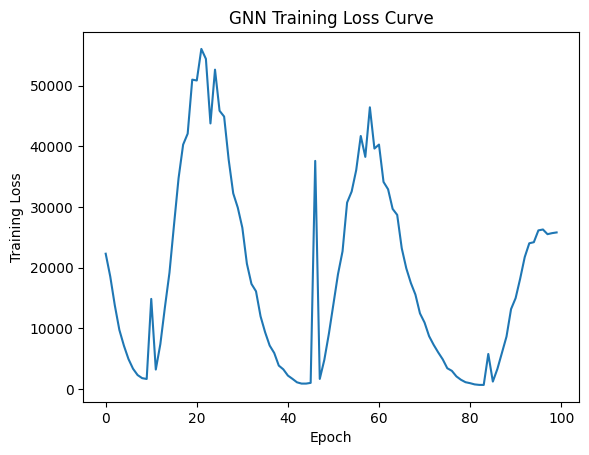

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("GNN Training Loss Curve")
plt.show()


1.2 ROC Curve
Generate scores for ROC

In [34]:
model.eval()

z = model.encode(
    data_lp.x.to(device),
    data_lp.train_pos_edge_index.to(device)
)

pos_out = model.decode(z, data_lp.test_pos_edge_index.to(device))
neg_out = model.decode(z, data_lp.test_neg_edge_index.to(device))

y_true = torch.cat([
    torch.ones(pos_out.size(0)),
    torch.zeros(neg_out.size(0))
]).cpu().numpy()

y_score = torch.cat([pos_out, neg_out]).cpu().detach().numpy()

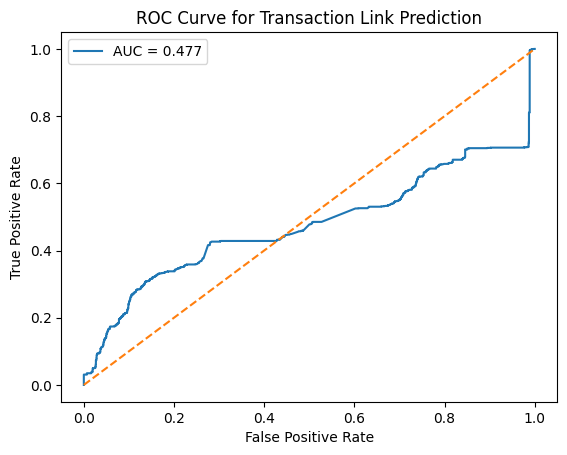

In [35]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Transaction Link Prediction")
plt.legend()
plt.show()


In [36]:
import numpy as np

np.save("node_embeddings.npy", embeddings)


In [37]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)


In [38]:
fraudulent_wallets.to_csv("fraudulent_wallets.csv", index=False)


In [39]:
df[["from_id", "to_id"]].to_csv("edges.csv", index=False)


node_embeddings.npy

label_encoder.pkl

fraudulent_wallets.csv

edges.csv


In [41]:
import numpy as np

np.save("loss_history.npy", np.array(loss_history))


In [44]:
model.eval()

z = model.encode(
    data_lp.x.to(device),
    data_lp.train_pos_edge_index.to(device)
)

pos_out = model.decode(z, data_lp.test_pos_edge_index.to(device))
neg_out = model.decode(z, data_lp.test_neg_edge_index.to(device))

y_true = torch.cat([
    torch.ones(pos_out.size(0)),
    torch.zeros(neg_out.size(0))
]).cpu().numpy()

y_score = torch.cat([pos_out, neg_out]).cpu().detach().numpy()

In [45]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)


In [46]:
np.savez(
    "roc_data.npz",
    fpr=fpr,
    tpr=tpr,
    auc=roc_auc
)


loss_history.npy

roc_data.npz


In [47]:
from torch_geometric.utils import negative_sampling
import torch.nn.functional as F

def train():
    model.train()
    optimizer.zero_grad()

    # Encode node embeddings
    z = model.encode(
        data_lp.x.to(device),
        data_lp.train_pos_edge_index.to(device)
    )

    # Positive edges
    pos_edge_index = data_lp.train_pos_edge_index.to(device)

    # Negative edge sampling
    neg_edge_index = negative_sampling(
        edge_index=pos_edge_index,
        num_nodes=data_lp.num_nodes,
        num_neg_samples=pos_edge_index.size(1)
    )

    # Decode
    pos_out = model.decode(z, pos_edge_index)
    neg_out = model.decode(z, neg_edge_index)

    # Labels
    out = torch.cat([pos_out, neg_out])
    labels = torch.cat([
        torch.ones(pos_out.size(0)),
        torch.zeros(neg_out.size(0))
    ]).to(device)

    # Loss
    loss = F.binary_cross_entropy_with_logits(out, labels)
    loss.backward()
    optimizer.step()

    return loss.item()


In [48]:
num_epochs = 100
loss_history = []

for epoch in range(1, num_epochs + 1):
    loss = train()
    loss_history.append(loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Training Loss: {loss:.4f}")


Epoch 010 | Training Loss: 7870.9883
Epoch 020 | Training Loss: 782.8133
Epoch 030 | Training Loss: 6511.6948
Epoch 040 | Training Loss: 20468.5742
Epoch 050 | Training Loss: 9096.1074
Epoch 060 | Training Loss: 1307.4969
Epoch 070 | Training Loss: 5410.6016
Epoch 080 | Training Loss: 14671.2607
Epoch 090 | Training Loss: 8643.2734
Epoch 100 | Training Loss: 823.0524


In [49]:
import numpy as np

np.save("loss_history.npy", np.array(loss_history))
print("loss_history.npy saved successfully")


loss_history.npy saved successfully


In [50]:
loss_history[:5], loss_history[-5:]


([20741.61328125,
  21052.576171875,
  18873.951171875,
  17373.271484375,
  15950.556640625],
 [1126.32470703125,
  813.2666015625,
  623.3314819335938,
  681.4497680664062,
  823.0523681640625])